[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/05-deep-learning-pytorch/01_pytorch_mlp.ipynb)

# Building Neural Networks with PyTorch

This notebook introduces the end-to-end workflow for training a multi-layer perceptron (MLP) in PyTorch. We will use the handwritten digits dataset from scikit-learn so the notebook runs quickly in a classroom setting.

## Learning goals

By the end of this notebook, you should be able to:
- prepare data for PyTorch with `TensorDataset` and `DataLoader`,
- define an MLP with `nn.Module`,
- train with Adam and cross-entropy loss, and
- visualize learning curves and model performance.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## Load a dataset

The digits dataset contains 8x8 grayscale images of handwritten digits. Each example will be flattened into a vector of 64 features before entering the MLP.

In [2]:
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Class labels:', np.unique(y))

Feature matrix shape: (1797, 64)
Target shape: (1797,)
Class labels: [0 1 2 3 4 5 6 7 8 9]


## Visualize a few examples

Even though an MLP does not explicitly use spatial structure, it is still helpful to inspect the original images.

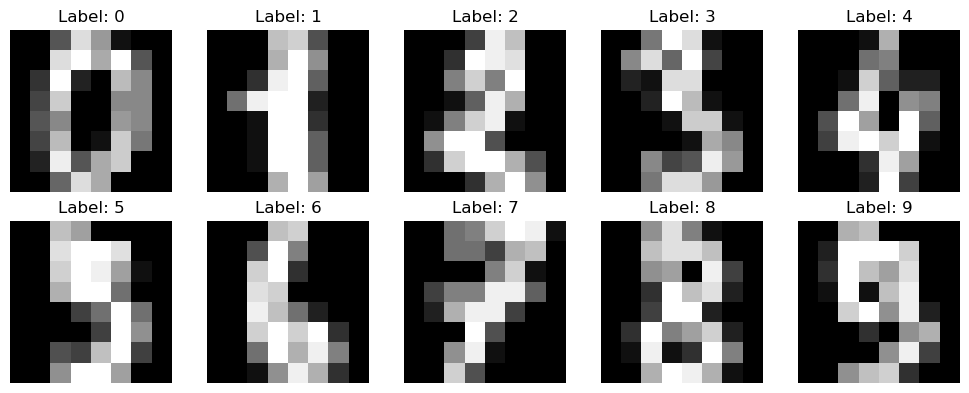

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), digits.images[:10], y[:10]):
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.tight_layout()

## Split and standardize the data

Neural networks often train more smoothly when input features are standardized. We will create training, validation, and test splits.

In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t = torch.tensor(y_val, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

## Build DataLoaders

`DataLoader` handles batching, shuffling, and iteration. This makes the training loop cleaner and more scalable.

In [5]:
batch_size = 64

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size)

xb, yb = next(iter(train_loader))
print('Batch feature shape:', xb.shape)
print('Batch label shape:', yb.shape)

Batch feature shape: torch.Size([64, 64])
Batch label shape: torch.Size([64])


## Define the MLP

We will use two hidden layers, ReLU activations, and dropout for regularization.

In [6]:
class DigitsMLP(nn.Module):
    def __init__(self, input_dim=64, hidden_1=128, hidden_2=64, num_classes=10, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_1, hidden_2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = DigitsMLP().to(device)
model

DigitsMLP(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

## Loss function and optimizer

`CrossEntropyLoss` is the standard loss for multi-class classification. Adam is a strong default optimizer for small and medium-sized experiments.

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

## Helper functions

To keep the training loop organized, we will separate one-epoch training from evaluation.

In [8]:
# HW 3 asks you to write `train_one_epoch(model, loader, optimizer, loss_fn)`
# yourself, so this notebook does not hand you that function. What it shows is
# the five steps it has to contain, in the order they must happen -- see the
# training loop two cells down, where they appear inline.
#
# `evaluate` is a different matter: it is not graded, and you need it here to
# watch validation loss alongside training loss.

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        total_loss += loss.item() * X_batch.size(0)
        total_correct += (logits.argmax(dim=1) == y_batch).sum().item()
        total_examples += X_batch.size(0)

    model.train()
    return total_loss / total_examples, total_correct / total_examples


## Train the network

The core pattern is always the same: forward pass, compute loss, backpropagate, and step the optimizer.

In [9]:
num_epochs = 30
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(num_epochs):
    # --- train one epoch, inline (see the cell above) ---
    model.train()
    run_loss = run_correct = seen = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * len(y_batch)
        run_correct += (logits.argmax(1) == y_batch).sum().item()
        seen += len(y_batch)
    train_loss, train_acc = run_loss / seen, run_correct / seen

    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch + 1:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"train_acc={train_acc:.3f} | val_acc={val_acc:.3f}")


Epoch 01/30 | train_loss=2.1630 | val_loss=1.9285 | train_acc=0.352 | val_acc=0.733
Epoch 05/30 | train_loss=0.3168 | val_loss=0.2636 | train_acc=0.920 | val_acc=0.926
Epoch 10/30 | train_loss=0.1164 | val_loss=0.1562 | train_acc=0.967 | val_acc=0.948


Epoch 15/30 | train_loss=0.0626 | val_loss=0.1293 | train_acc=0.986 | val_acc=0.956
Epoch 20/30 | train_loss=0.0418 | val_loss=0.1223 | train_acc=0.993 | val_acc=0.963
Epoch 25/30 | train_loss=0.0270 | val_loss=0.1200 | train_acc=0.994 | val_acc=0.963


Epoch 30/30 | train_loss=0.0236 | val_loss=0.1302 | train_acc=0.996 | val_acc=0.963


## Plot the learning curves

Loss curves help diagnose optimization behavior, while accuracy curves show how predictive performance changes over time.

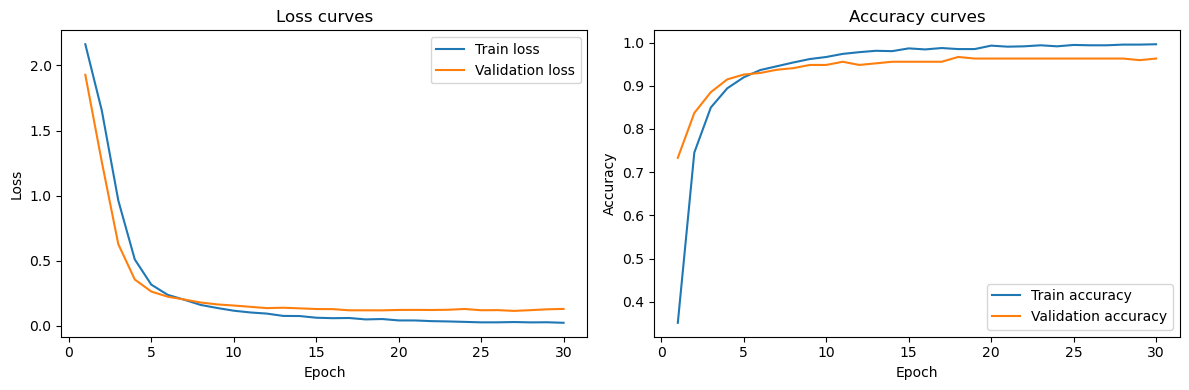

In [10]:
epochs = np.arange(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train loss')
axes[0].plot(epochs, history['val_loss'], label='Validation loss')
axes[0].set_title('Loss curves')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train accuracy')
axes[1].plot(epochs, history['val_acc'], label='Validation accuracy')
axes[1].set_title('Accuracy curves')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()

## Evaluate on the held-out test set

Once the model looks reasonable on the validation set, we estimate final performance on the test split.

In [11]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_acc:.3f}')

Test loss: 0.0363
Test accuracy: 0.989


## Confusion matrix and classification report

These summaries show which digits the model confuses most often.

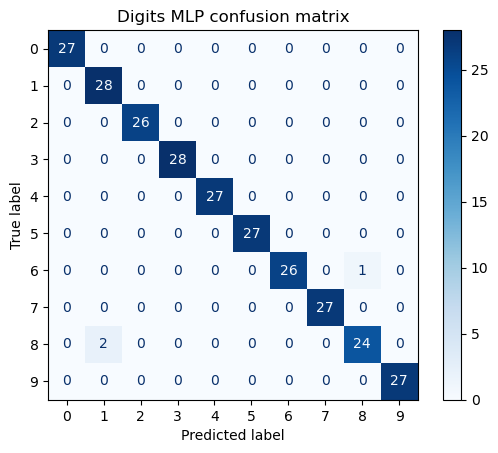

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.93      1.00      0.97        28
           2       1.00      1.00      1.00        26
           3       1.00      1.00      1.00        28
           4       1.00      1.00      1.00        27
           5       1.00      1.00      1.00        27
           6       1.00      0.96      0.98        27
           7       1.00      1.00      1.00        27
           8       0.96      0.92      0.94        26
           9       1.00      1.00      1.00        27

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



In [12]:
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        logits = model(X_batch.to(device))
        preds = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Digits MLP confusion matrix')
plt.show()

print(classification_report(all_targets, all_preds))

## Wrap-up

This notebook demonstrated a complete PyTorch pipeline for an MLP: prepare tensors, build the model, train with mini-batches, and evaluate using both curves and confusion matrices. The same skeleton will be reused throughout this module.